In [20]:
import pandas as pd
import numpy as num_paths
import matplotlib.pyplot as psnrResault
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from matplotlib import pyplot as plt

import pickle

In [21]:
df=pd.read_csv("data21.11.2024.csv")

In [22]:
df=pd.DataFrame(df)
df.head()

,host,avgRTT,packetLoss,latency,hopCount,bandwidth,psnr,ssim_first,ssim_second,kaynak,...,h10gelen,h10giden,h10toplam,h14gelen,h14giden,h14toplam,type,server,tahmin_mos,real_mos
0,h7,258.305,0.0,64,3,10000000,32.497785,0.987272,18.952240,67209812,...,9746,1041430,1051176,9774,1046860,1056634,6,h14,0,4
1,h8,221.283,0.0,40,2,10000000,25.858796,0.963395,14.364558,67209812,...,10698,1047640,2109514,1917520,1058092,4032246,6,h14,[4.30576841],4
2,h9,280.149,0.0,62,3,10000000,21.589305,0.918842,10.906686,67209812,...,11664,1055366,3176544,5922754,1077567,11032567,6,h14,[4.01532466],3
3,h11,215.956,0.0,45,2,10000000,36.507699,0.996039,24.022245,67209812,...,12630,1066302,4255476,11962986,1106125,24101678,6,h10,[3.97113222],5
4,h12,331.428,0.0,65,3,10000000,34.859543,0.994015,22.229087,67209812,...,1420026,1083418,6758920,18242840,1136073,43480591,6,h10,[3.89867304],5


In [23]:
df.dropna(inplace=True)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
avgRTT,501.0,7.719392e+02,4.383821e+02,1.530840e+02,3.190030e+02,7.282400e+02,1.217746e+03,1.685973e+03
packetLoss,501.0,1.330672e-01,2.218227e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.444444e+01
latency,501.0,7.042715e+01,2.507790e+01,1.400000e+01,5.100000e+01,7.000000e+01,8.300000e+01,1.510000e+02
hopCount,501.0,2.660679e+00,7.903358e-01,1.000000e+00,2.000000e+00,3.000000e+00,3.000000e+00,5.000000e+00
bandwidth,501.0,1.000000e+07,0.000000e+00,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07
psnr,501.0,2.298717e+01,6.185472e+00,1.484019e+01,1.769052e+01,2.112114e+01,2.642454e+01,3.796985e+01
ssim_first,501.0,8.939961e-01,8.572931e-02,6.671770e-01,8.269590e-01,9.128220e-01,9.706310e-01,9.974720e-01
ssim_second,501.0,1.202214e+01,5.252635e+00,4.777868e+00,7.618510e+00,1.059595e+01,1.532108e+01,2.597268e+01
kaynak,501.0,6.720981e+07,0.000000e+00,6.720981e+07,6.720981e+07,6.720981e+07,6.720981e+07,6.720981e+07
kayitboyut,501.0,5.768110e+07,8.710342e+06,3.171942e+07,5.138022e+07,5.924454e+07,6.606029e+07,6.737101e+07


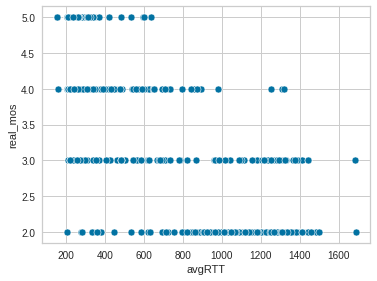

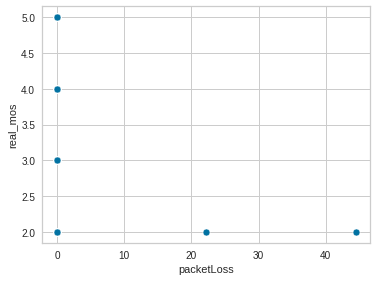

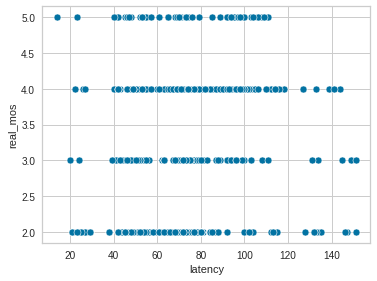

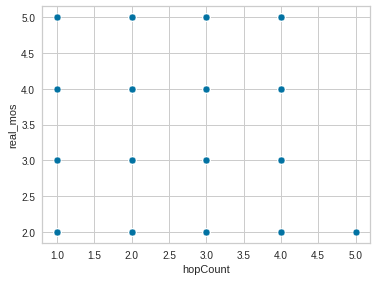

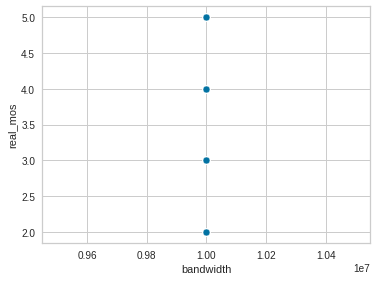

In [24]:
sayisal_veriler=["avgRTT","packetLoss","latency","hopCount","bandwidth"]
for i,deger in enumerate(sayisal_veriler):
    plt.figure(figsize=(20,20))
    ax=plt.subplot(4,3,i+1)
    sns.scatterplot(x=deger,y="real_mos",data=df)
    plt.show()

In [25]:
# sns.displot(df)

In [26]:
df["real_mos"].value_counts()

real_mos
2    207
4    135
3    105
5     54
Name: count, dtype: int64

In [27]:
y=df["real_mos"]
x=df.drop(["real_mos","tahmin_mos","host","ssim_first","ssim_second","type","psnr","server","packetLoss","kaynak","kayitboyut","kayip","kayip_orani"],axis="columns")
y


0      4
1      4
2      3
3      5
4      5
      ..
496    4
497    4
498    4
499    2
500    2
Name: real_mos, Length: 501, dtype: int64

In [28]:
x.describe()

,avgRTT,latency,hopCount,bandwidth,h10gelen,h10giden,h10toplam,h14gelen,h14giden,h14toplam
count,501.000000,501.000000,501.000000,501.0,5.010000e+02,5.010000e+02,5.010000e+02,5.010000e+02,5.010000e+02,5.010000e+02
mean,771.939204,70.427146,2.660679,10000000.0,3.827496e+07,2.480220e+07,2.681572e+08,5.039130e+07,2.516187e+07,3.168000e+08
std,438.382075,25.077902,0.790336,0.0,3.625271e+07,6.242623e+07,4.124880e+08,4.847813e+07,6.310808e+07,4.482440e+08
min,153.084000,14.000000,1.000000,10000000.0,9.446000e+03,5.379200e+04,6.367000e+04,9.326000e+03,5.284400e+04,6.274400e+04
25%,319.003000,51.000000,2.000000,10000000.0,4.960500e+06,5.116170e+05,1.281506e+07,1.010838e+07,5.317990e+05,2.239521e+07
50%,728.240000,70.000000,3.000000,10000000.0,2.940698e+07,1.381395e+06,9.975116e+07,3.290779e+07,1.434375e+06,1.304119e+08
75%,1217.746000,83.000000,3.000000,10000000.0,6.299305e+07,6.446424e+06,3.544281e+08,8.442204e+07,6.698421e+06,4.587961e+08
max,1685.973000,151.000000,5.000000,10000000.0,1.440623e+08,4.071262e+08,2.950395e+09,1.943895e+08,4.102791e+08,2.875070e+09


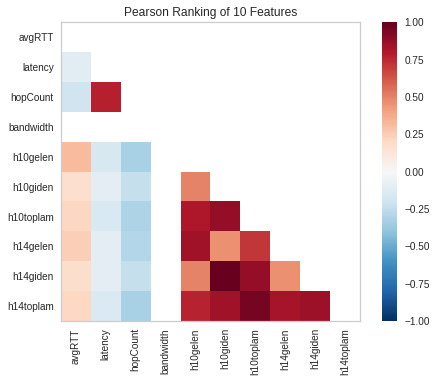

<AxesSubplot:title={'center':'Pearson Ranking of 10 Features'}>

In [29]:
from yellowbrick.features import Rank2D
visualizer=Rank2D(algorithm="pearson")
visualizer.fit(x,y)
visualizer.transform(x)
visualizer.show()

In [30]:
x.describe().T

,count,mean,std,min,25%,50%,75%,max
avgRTT,501.0,7.719392e+02,4.383821e+02,1.530840e+02,3.190030e+02,7.282400e+02,1.217746e+03,1.685973e+03
latency,501.0,7.042715e+01,2.507790e+01,1.400000e+01,5.100000e+01,7.000000e+01,8.300000e+01,1.510000e+02
hopCount,501.0,2.660679e+00,7.903358e-01,1.000000e+00,2.000000e+00,3.000000e+00,3.000000e+00,5.000000e+00
bandwidth,501.0,1.000000e+07,0.000000e+00,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07
h10gelen,501.0,3.827496e+07,3.625271e+07,9.446000e+03,4.960500e+06,2.940698e+07,6.299305e+07,1.440623e+08
h10giden,501.0,2.480220e+07,6.242623e+07,5.379200e+04,5.116170e+05,1.381395e+06,6.446424e+06,4.071262e+08
h10toplam,501.0,2.681572e+08,4.124880e+08,6.367000e+04,1.281506e+07,9.975116e+07,3.544281e+08,2.950395e+09
h14gelen,501.0,5.039130e+07,4.847813e+07,9.326000e+03,1.010838e+07,3.290779e+07,8.442204e+07,1.943895e+08
h14giden,501.0,2.516187e+07,6.310808e+07,5.284400e+04,5.317990e+05,1.434375e+06,6.698421e+06,4.102791e+08
h14toplam,501.0,3.168000e+08,4.482440e+08,6.274400e+04,2.239521e+07,1.304119e+08,4.587961e+08,2.875070e+09


In [31]:
from sklearn.model_selection import train_test_split
XTrain,XTest,yTrain,yTest=train_test_split(x,y,test_size=0.10, random_state=42)

In [32]:
yTest.value_counts()

real_mos
2    22
4    18
3     8
5     3
Name: count, dtype: int64

In [33]:
from sklearn.linear_model import LinearRegression
LinModel=LinearRegression()
LinModel.fit(XTrain,yTrain)
tahmin=LinModel.predict(XTest)
from sklearn.metrics import r2_score
print(r2_score(yTest,tahmin))

0.4948012603336037


In [34]:
from sklearn.ensemble import RandomForestRegressor
for i in range(1,20,1):
    rand=RandomForestRegressor(max_depth=i,)
    rand.fit(XTrain,yTrain)
    tahminRand=rand.predict(XTest)
    print(f"max_depth : {i} --> score r2 : eğitim:{r2_score(yTrain,rand.predict(XTrain))} test: {r2_score(yTest,tahminRand)}")

max_depth : 1 --> score r2 : eğitim:0.6005075570327235 test: 0.5871571832743252
max_depth : 2 --> score r2 : eğitim:0.786922331217143 test: 0.495617215153735
max_depth : 3 --> score r2 : eğitim:0.8249898949371425 test: 0.461665267380011
max_depth : 4 --> score r2 : eğitim:0.8668768205672602 test: 0.43546197222207816
max_depth : 5 --> score r2 : eğitim:0.9016190526926893 test: 0.42325716722384765
max_depth : 6 --> score r2 : eğitim:0.9282677041616815 test: 0.4248276393238982
max_depth : 7 --> score r2 : eğitim:0.9456389905968313 test: 0.41991217984658824
max_depth : 8 --> score r2 : eğitim:0.956504707970327 test: 0.41053708991949167
max_depth : 9 --> score r2 : eğitim:0.963857286862639 test: 0.4075289509877934
max_depth : 10 --> score r2 : eğitim:0.9679180958224041 test: 0.4018770190968518
max_depth : 11 --> score r2 : eğitim:0.9699584372944849 test: 0.4142330979103718
max_depth : 12 --> score r2 : eğitim:0.9681956212329353 test: 0.4288225208022962
max_depth : 13 --> score r2 : eğitim:0

In [35]:
from sklearn.neighbors import KNeighborsRegressor
for i in range(1,20,1):
    KNN=KNeighborsRegressor(n_neighbors=i)
    KNN.fit(XTrain,yTrain)
    tahminKNN=KNN.predict(XTest)
    print(f"n_neigbors : {i} --> score r2 : eğitim:{r2_score(yTrain,KNN.predict(XTrain))} test: {r2_score(yTest,tahminKNN)}")

n_neigbors : 1 --> score r2 : eğitim:1.0 test: -0.0785498489425982
n_neigbors : 2 --> score r2 : eğitim:0.7978869446994844 test: 0.1573829305135952
n_neigbors : 3 --> score r2 : eğitim:0.7309573416201709 test: 0.15898791540785495
n_neigbors : 4 --> score r2 : eğitim:0.700927303305318 test: 0.21155117069486407
n_neigbors : 5 --> score r2 : eğitim:0.6838494950208347 test: 0.205725075528701
n_neigbors : 6 --> score r2 : eğitim:0.6705386150151846 test: 0.24565709969788507
n_neigbors : 7 --> score r2 : eğitim:0.6570878333676855 test: 0.2641963129662741
n_neigbors : 8 --> score r2 : eğitim:0.6413983045236245 test: 0.2578951095166163
n_neigbors : 9 --> score r2 : eğitim:0.6351456866853433 test: 0.2640847040393869
n_neigbors : 10 --> score r2 : eğitim:0.6314490783247404 test: 0.270823262839879
n_neigbors : 11 --> score r2 : eğitim:0.6262671174307846 test: 0.2894559436718186
n_neigbors : 12 --> score r2 : eğitim:0.6217484241471855 test: 0.27147060674723056
n_neigbors : 13 --> score r2 : eğitim:

In [36]:
from sklearn.tree import DecisionTreeRegressor
for i in range(1,20,1):
    DT=DecisionTreeRegressor(max_depth=i)
    DT.fit(XTrain,yTrain)
    tahminDT=DT.predict(XTest)
    print(f"max_depth : {i} --> score r2 : eğitim:{r2_score(yTrain,DT.predict(XTrain))} test: {r2_score(yTest,tahminDT)}")

max_depth : 1 --> score r2 : eğitim:0.5731113740691306 test: 0.5250410942146336
max_depth : 2 --> score r2 : eğitim:0.7560611775244583 test: 0.4786976610164
max_depth : 3 --> score r2 : eğitim:0.8031503748858868 test: 0.43844425277012233
max_depth : 4 --> score r2 : eğitim:0.8493520751968342 test: 0.41441822435708564
max_depth : 5 --> score r2 : eğitim:0.8824578967840321 test: 0.34347194644297596
max_depth : 6 --> score r2 : eğitim:0.9136645888252234 test: 0.2704657683373579
max_depth : 7 --> score r2 : eğitim:0.9381771135338096 test: 0.25119229078527183
max_depth : 8 --> score r2 : eğitim:0.9619897723577362 test: 0.26999874618571396
max_depth : 9 --> score r2 : eğitim:0.9757324632955857 test: 0.22191696463306188
max_depth : 10 --> score r2 : eğitim:0.9860552876743992 test: 0.24272322464783325
max_depth : 11 --> score r2 : eğitim:0.9931718562398475 test: 0.22584556740936557
max_depth : 12 --> score r2 : eğitim:0.9941733173246698 test: 0.22686807653575025
max_depth : 13 --> score r2 : e

In [37]:
from sklearn.ensemble import GradientBoostingRegressor
for i in range(1,10,1):
    gbr=GradientBoostingRegressor(max_depth=i,loss='squared_error')
    gbr.fit(XTrain,yTrain)
    tahminGbr=gbr.predict(XTest)
    print(f"max_depth : {i} --> score r2 : eğitim:{r2_score(yTrain,gbr.predict(XTrain))} test: {r2_score(yTest,tahminGbr)}")

max_depth : 1 --> score r2 : eğitim:0.814471402905043 test: 0.48534728363452784
max_depth : 2 --> score r2 : eğitim:0.8785237082114942 test: 0.4717277751777089
max_depth : 3 --> score r2 : eğitim:0.9408390250558788 test: 0.4843180008859943
max_depth : 4 --> score r2 : eğitim:0.9779154787716782 test: 0.45341524191464544
max_depth : 5 --> score r2 : eğitim:0.9938900808437193 test: 0.4324152012315985
max_depth : 6 --> score r2 : eğitim:0.9989509132736359 test: 0.3999277741365447
max_depth : 7 --> score r2 : eğitim:0.9999049762810712 test: 0.36318374325127656
max_depth : 8 --> score r2 : eğitim:0.9999924419156626 test: 0.3750129089597133
max_depth : 9 --> score r2 : eğitim:0.9999996508667057 test: 0.38156750580196497


In [38]:
from xgboost import XGBRegressor
xgb=XGBRegressor()
xgb.fit(XTrain,yTrain)
tahminXGB=xgb.predict(XTest)
print(r2_score(yTest,tahminXGB))

0.4214278211425344


In [39]:
from sklearn.linear_model import RANSACRegressor
ransac=RandomForestRegressor(random_state=42)
ransac.fit(XTrain,yTrain)
tahminRansac=ransac.predict(XTest)
print(f"ransac -> {r2_score(yTest,tahminRansac)}")

ransac -> 0.40143757552870085


In [41]:
from sklearn.ensemble import ExtraTreesRegressor
for i in range(1,10,1):
    exTree=ExtraTreesRegressor(max_depth=i)
    exTree.fit(XTrain,yTrain)
    tahminExTree=exTree.predict(XTest)
    print(f"max_depth : {i} --> score r2 : eğitim:{r2_score(yTrain,exTree.predict(XTrain))} test: {r2_score(yTest,tahminExTree)}")

   # model_pkl_file=f"extraTreeRegressor{i}.pkl"

    #with open(model_pkl_file,'wb') as file:
#        pickle.dump(model,file)

max_depth : 1 --> score r2 : eğitim:0.57737273698895 test: 0.48006398815726536
max_depth : 2 --> score r2 : eğitim:0.7311723547471589 test: 0.5061948308052984
max_depth : 3 --> score r2 : eğitim:0.7748265107692196 test: 0.5065569612263173
max_depth : 4 --> score r2 : eğitim:0.8139594519980043 test: 0.4986533838185204
max_depth : 5 --> score r2 : eğitim:0.851707601403856 test: 0.4845934762733829
max_depth : 6 --> score r2 : eğitim:0.887744454404015 test: 0.4664942837327013
max_depth : 7 --> score r2 : eğitim:0.9217986295936029 test: 0.45816242253374284
max_depth : 8 --> score r2 : eğitim:0.945846582066601 test: 0.4259010786873041
max_depth : 9 --> score r2 : eğitim:0.9621473515540442 test: 0.4315616396423132


In [26]:
model=ExtraTreesRegressor(max_depth=7)
model.fit(XTrain,yTrain)
model_pkl_file="extraTreeRegressor.pkl"

with open(model_pkl_file,'wb') as file:
    pickle.dump(model,file)

In [27]:
tahminModel=model.predict(XTest)
print(f"max_depth : {7} --> score r2 : eğitim:{r2_score(yTrain,exTree.predict(XTrain))} test: {r2_score(yTest,tahminModel)}")

max_depth : 9 --> score r2 : eğitim:0.9621761832591909 test: 0.8261250365670159


In [30]:
tahminModel

array([2.01739659, 2.0012492 , 2.49251701, 3.20861354, 3.78041013,
       3.57785471, 2.07904362, 3.35094331, 4.47123824, 3.87430315,
       4.02565654, 3.33928884, 3.97134777, 2.182441  , 2.05562965,
       2.44551569, 4.07616865, 2.09218329, 4.31477583, 2.25724273,
       3.14888233, 3.59662965, 3.86699021, 2.02299076, 2.31829595,
       3.56743105, 3.57841984, 2.11469036, 2.00043723, 3.91380324,
       2.89949053, 2.99425313, 2.04373882, 2.00446965, 3.46232976,
       2.00043723, 2.15948487, 3.43608468, 2.00297931, 2.23666145,
       2.06498223, 3.31493322, 4.10583084, 3.55288056, 3.88345205,
       3.93601186, 3.82410731, 2.23010196, 2.31199725, 3.86231762,
       4.43086643, 2.66756034, 4.18709621, 2.04791983, 2.00170374,
       2.93629744, 3.98111362, 3.85382499, 2.17651944])

In [22]:
tahminGbr

array([2.00005305, 2.00004194, 2.000069  , 2.99217945, 3.92989164,
       3.63271253, 2.00004554, 3.34310607, 3.87907183, 3.93495963,
       3.86075751, 3.99903705, 3.999522  , 2.00002238, 2.00004552,
       1.99817866, 4.22622588, 2.00004479, 3.86114631, 2.00014202,
       2.78804528, 3.35369772, 4.00353725, 2.00004552, 2.00048913,
       3.07467731, 3.50821419, 2.00004579, 2.00004194, 4.03963844,
       2.99980735, 3.95384645, 2.00004579, 2.00004196, 3.99859104,
       2.00004552, 2.00006721, 3.09827549, 2.00004552, 2.13135353,
       2.000041  , 3.15477885, 4.09716166, 3.99900706, 3.95952435,
       3.96007127, 3.82177817, 2.00002901, 2.00020548, 3.97671998,
       4.66748364, 2.9519213 , 3.99712628, 2.00004554, 2.00004194,
       2.99998112, 3.98401837, 3.59781216, 2.07983832])

In [23]:
yTest

525    2
286    2
517    2
333    3
211    4
90     4
301    2
181    4
549    4
137    4
550    4
70     4
397    4
236    2
425    2
155    3
210    4
373    2
506    5
182    3
282    3
229    4
2      5
563    2
200    2
63     4
55     4
588    2
288    2
29     4
477    2
233    2
589    2
251    2
82     4
322    2
283    2
176    3
456    2
555    2
250    2
212    3
177    5
10     4
429    4
529    4
6      4
492    2
351    2
279    3
145    5
554    3
72     4
454    2
252    2
426    3
101    4
86     4
382    3
Name: mos, dtype: int64

In [24]:
yTrain

318    2
76     4
532    3
573    4
30     4
      ..
71     3
106    4
272    2
438    2
102    4
Name: mos, Length: 529, dtype: int64

In [25]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
XTrain[sayisal_veriler]=scaler.fit_transform(XTrain[sayisal_veriler])
XTest[sayisal_veriler]=scaler.transform(XTest[sayisal_veriler])

KeyError: "['packetLoss'] not in index"

In [ ]:
from sklearn.linear_model import LinearRegression
LogModel=LinearRegression()
LogModel.fit(XTrain,yTrain)
tahmin=LogModel.predict(XTest)
from sklearn.metrics import r2_score
print(r2_score(yTest,tahmin))

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
for i in range(1,20,1):
    KNN=KNeighborsRegressor(n_neighbors=i)
    KNN.fit(XTrain,yTrain)
    tahminKNN=KNN.predict(XTest)
    print(f"n_neigbors : {i} --> score r2 : eğitim:{r2_score(yTrain,KNN.predict(XTrain))} test: {r2_score(yTest,tahminKNN)}")

In [ ]:
from sklearn.ensemble import RandomForestRegressor
for i in range(1,20,1):
    rand=RandomForestRegressor(max_depth=i,bootstrap=True,criterion="friedman_mse",max_features='log2',max_leaf_nodes=None,n_estimators=100,n_jobs=1,random_state=42)
    rand.fit(XTrain,yTrain)
    tahminRand=rand.predict(XTest)
    print(f"max_depth : {i} --> score r2 : eğitim:{r2_score(yTrain,rand.predict(XTrain))} test: {r2_score(yTest,tahminRand)}")

In [ ]:
from sklearn.tree import DecisionTreeRegressor
for i in range(1,20,1):
    DT=DecisionTreeRegressor(max_depth=i)
    DT.fit(XTrain,yTrain)
    tahminDT=DT.predict(XTest)
    print(f"max_depth : {i} --> score r2 : eğitim:{r2_score(yTrain,DT.predict(XTrain))} test: {r2_score(yTest,tahminDT)}")

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
for i in range(1,10,1):
    gbr=GradientBoostingRegressor(max_depth=i,loss='squared_error')
    gbr.fit(XTrain,yTrain)
    tahminGbr=gbr.predict(XTest)
    print(f"max_depth : {i} --> score r2 : eğitim:{r2_score(yTrain,gbr.predict(XTrain))} test: {r2_score(yTest,tahminGbr)}")